In [91]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import geopandas as gpd

from itertools import chain
import shapely.vectorized as sv

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.colors import BoundaryNorm

sys.path.append(os.path.abspath("../.."))
from function import DOWN_raw
from function import ART_downscale as ART_down
from function import ART_statistic as ART_stat

import warnings
warnings.filterwarnings('ignore')

In [92]:
product, time_reso = 'ENSEMBLE', '1dy'

# product, time_reso = 'IMERG', '1dy'
# product, time_reso = 'CMORPH', '3h'
# product, time_reso = 'CHIRPS', '1dy'
# product, time_reso = 'ERA5', '3h'

# product, time_reso = 'MSWEP', '3h'
# product, time_reso = 'GSMaP', '3h'

In [93]:
dir_base = os.path.join('/','media','arturo','T9','Data','Italy')
obs_base = os.path.join('/','media','arturo','T9','Data','Italy','Rain_Gauges_QC')
veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')

dir_cal = os.path.join('/','media','arturo','T9','Data','Italy','Rain_Gauges_QC','CAL_VAL', 'Calibration')
dir_val = os.path.join('/','media','arturo','T9','Data','Italy','Rain_Gauges_QC','CAL_VAL', 'Validation')

In [94]:
if os.path.exists(veneto_dir):
    ITALY = gpd.read_file(os.path.join(veneto_dir,'Italy_clear.geojson'))
else:
    raise SystemExit(f"File not found: {veneto_dir}")

lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'

In [95]:
if product == 'ENSEMBLE':
    dir_sat = os.path.join(dir_base, 'Satellite', '5_ENSEMBLE')
    inputfile = f'ITALY_DOWN_{product}_{time_reso}_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'
elif product == 'CHIRPS':
    dir_sat = os.path.join(dir_base, 'Satellite', '5_DOWN')
    inputfile = f'ITALY_DOWN_{product}_{time_reso}_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson_MEVD.nc'
else:
    dir_sat = os.path.join(dir_base, 'Satellite', '5_DOWN')
    inputfile = f'ITALY_DOWN_{product}_{time_reso}_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'

data_dir = os.path.join(dir_sat, inputfile)
DATA = xr.open_dataset(data_dir)

lons, lats = DATA.lon.values, DATA.lat.values
lon2d, lat2d = np.meshgrid(lons, lats)
years = DATA.year.values

In [96]:
italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d, lat2d)

In [97]:
pos = 3
Tr = [5,  10,  20,  50, 100, 200]
Fi = 1 - 1/np.array(Tr)
print(f'Return Time: {Tr[pos]} yrs')

Return Time: 50 yrs


In [98]:
def bias_correction_seed(METADATA_input, DATA_input):

    Factor_df = []

    lat_list, lon_list = [], []
    factor_N_list, factor_C_list, factor_W_list = [], [], []
    QUANTILE, file_list = [], []
    Nval_list = []

    for nn in range(len(METADATA_input)):
        file = METADATA_input['File'].values[nn]
        ISO = METADATA_input['ISO'].values[nn]
        lon_obs = METADATA_input['Lon'].values[nn]
        lat_obs = METADATA_input['Lat'].values[nn]

        DF_OBS = pd.read_csv(os.path.join(obs_base,'Weibull','1dy',ISO,file)) 
        DF_OBS = DF_OBS.drop(columns='NaN')

        sat_pixel = DATA_input.sel(lat=lat_obs, lon=lon_obs, method='nearest')

        sat_n = sat_pixel.NYs.values
        sat_year = sat_pixel.year.values

        DF_SAT = pd.DataFrame({'Year':sat_pixel.year.values, 'Ns':sat_pixel.NYs.values, 'Cs':sat_pixel.CYs.values, 'Ws':sat_pixel.WYs.values})

        merged_df = pd.merge(DF_SAT, DF_OBS, on='Year', how='left')
        merged_df_clean = merged_df.dropna(subset=['N'])

        factor_N = np.nanmean(merged_df_clean.N.values) / np.nanmean(merged_df_clean.Ns.values)
        factor_C = np.nanmean(merged_df_clean.C.values) / np.nanmean(merged_df_clean.Cs.values)
        factor_W = np.nanmean(merged_df_clean.W.values) / np.nanmean(merged_df_clean.Ws.values)

        x0 = np.nanmean(merged_df_clean.C.values)
        OBS_Q, flag = DOWN_raw.mev_quant_update(Fi, x0, merged_df_clean.N.values, merged_df_clean.C.values, merged_df_clean.W.values, thresh=1)
        OBS_Q2 = np.where(flag, OBS_Q, np.nan)

        lat_list.append(lat_obs)
        lon_list.append(lon_obs)
        factor_N_list.append(factor_N)
        factor_C_list.append(factor_C)
        factor_W_list.append(factor_W)
        file_list.append(file)
        QUANTILE.append(OBS_Q2[pos])
        Nval_list.append(len(merged_df_clean.N.values))

    Factor_N_df = pd.DataFrame({'lon':lon_list, 'lat':lat_list, 'factor':factor_N_list})
    Factor_C_df = pd.DataFrame({'lon':lon_list, 'lat':lat_list, 'factor':factor_C_list})
    Factor_W_df = pd.DataFrame({'lon':lon_list, 'lat':lat_list, 'factor':factor_W_list})

    factor_N_grid = ART_stat.interpolate_factors_to_grid(Factor_N_df, DATA, use_idw=True, power=2, n_neighbors=2, max_distance=5.0)
    factor_N_grid = factor_N_grid.where(mask_italy).values

    factor_C_grid = ART_stat.interpolate_factors_to_grid(Factor_C_df, DATA, use_idw=True, power=2, n_neighbors=2, max_distance=5.0)
    factor_C_grid = factor_C_grid.where(mask_italy).values

    factor_W_grid = ART_stat.interpolate_factors_to_grid(Factor_W_df, DATA, use_idw=True, power=2, n_neighbors=2, max_distance=5.0)
    factor_W_grid = factor_W_grid.where(mask_italy).values

    NYs = DATA.NYs.where(mask_italy).values
    CYs = DATA.CYs.where(mask_italy).values
    WYs = DATA.WYs.where(mask_italy).values

    if product == 'CHIRPS':
        NYs = np.where(NYs==0,np.nan,NYs)
        CYs = np.where(CYs==0,np.nan,CYs)
        WYs = np.where(WYs==0,np.nan,WYs)

    NYs_corrected = NYs*factor_N_grid
    CYs_corrected = CYs*factor_C_grid
    WYs_corrected = WYs*factor_W_grid

    SAT_corrected = xr.Dataset(
            data_vars={
                "NYs": (("year","lat","lon"), NYs_corrected),
                "CYs": (("year","lat","lon"), CYs_corrected),
                "WYs": (("year","lat","lon"), WYs_corrected),
                },
            coords={
                'year': years, 
                'lat': lats, 
                'lon': lons
                },
                attrs=dict(description=f"{product} Weibull parameters and MEV corrected applying in Italy",))

    SAT_corrected.NYs.attrs["units"] = "# days"
    SAT_corrected.NYs.attrs["long_name"] = "Corrected MEV Number of Wet Days"
    SAT_corrected.NYs.attrs["origname"] = "MEV Wet Days"

    SAT_corrected.CYs.attrs["units"] = "nondimensional"
    SAT_corrected.CYs.attrs["long_name"] = "Corrected MEV Scale Parameter"
    SAT_corrected.CYs.attrs["origname"] = "MEV Scale"

    SAT_corrected.WYs.attrs["units"] = "nondimensional"
    SAT_corrected.WYs.attrs["long_name"] = "Corrected MEV Shape Parameter"
    SAT_corrected.WYs.attrs["origname"] = "MEV Shape"

    SAT_corrected.lat.attrs["units"] = "degrees_north"
    SAT_corrected.lat.attrs["long_name"] = "Latitude"

    SAT_corrected.lon.attrs["units"] = "degrees_east"
    SAT_corrected.lon.attrs["long_name"] = "Longitude"
    
    return SAT_corrected

In [99]:
def Relative_error(METADATA_input, DATA_input, seed):
    Tr = [5,  10,  20,  50, 100, 200]
    Fi = 1 - 1/np.array(Tr)

    lon_list, lat_list, elev_list = [], [], []
    OBS_list, SAT_list, DOWN_list = [], [], []
    RE_DOWN_list, RE_SAT_list = [], []
    ME_DOWN_list, ME_SAT_list = [], []

    for nn in range(len(METADATA_input)):

        name = METADATA_input['File'].values[nn]
        ISO = METADATA_input['ISO'].values[nn]
        lat_obs = METADATA_input['Lat'].values[nn]
        lon_obs = METADATA_input['Lon'].values[nn]
        elev_obs = METADATA_input['DEM_Elevation'].values[nn]

        dir_station = os.path.join(dir_base,'Rain_Gauges_QC','Weibull','1dy',ISO,name)
        DF_OBS = pd.read_csv(dir_station)
        DF_OBS = DF_OBS.drop(columns='NaN')

        PREC_DOWN = DATA_input.sel(lat=lat_obs, lon=lon_obs, method='nearest')

        DF_SAT = pd.DataFrame({
                                'Year':PREC_DOWN.year.values, 
                                'Ns':PREC_DOWN.NYs.values, 'Cs':PREC_DOWN.CYs.values, 'Ws':PREC_DOWN.WYs.values})

        merged_df = pd.merge(DF_SAT, DF_OBS, on='Year', how='left')

        merged_df_clean = merged_df.dropna(subset=['N'])
        
        if merged_df_clean.Ns.values.sum() == 0 or np.isnan(merged_df_clean.Ns.values.sum()) == True:
            lon_list.append(np.nan)
            lat_list.append(np.nan)
            elev_list.append(np.nan)
            OBS_list.append(np.nan)
            SAT_list.append(np.nan)
            DOWN_list.append(np.nan)
            RE_SAT_list.append(np.nan)
            RE_DOWN_list.append(np.nan)
            ME_SAT_list.append(np.nan)
            ME_DOWN_list.append(np.nan)
        
        else:
            x0 = 9.0*np.nanmean(merged_df_clean.C.values)
            quant, flag = ART_down.mev_quant_update(Fi, x0, merged_df_clean.N.values, merged_df_clean.C.values, merged_df_clean.W.values, thresh=1)
            QQ_OBS = np.where(flag, quant, np.nan)

            x0 = 9.0*np.nanmean(merged_df_clean.Cs.values)
            quant, flag = ART_down.mev_quant_update(Fi, x0, merged_df_clean.Ns.values, merged_df_clean.Cs.values, merged_df_clean.Ws.values, thresh=1)
            QQ_SAT = np.where(flag, quant, np.nan)

            RE_SAT = (QQ_SAT - QQ_OBS) / QQ_OBS

            ME_SAT = QQ_SAT/QQ_OBS

            lon_list.append(lon_obs)
            lat_list.append(lat_obs)
            elev_list.append(elev_obs)
            OBS_list.append(QQ_OBS[3])
            SAT_list.append(QQ_SAT[3])
            RE_SAT_list.append(RE_SAT[3])
            ME_SAT_list.append(ME_SAT[3])

    elev_norm = (elev_list-np.nanmin(elev_list))/(np.nanmax(elev_list)-np.nanmin(elev_list))

    PD_RE  = pd.DataFrame({'Lon':lon_list,'Lat':lat_list, 'Elev':elev_list, 'Elev_norm':elev_norm, 'Mevd_OBS':OBS_list, 'Mevd_SAT':SAT_list, 'RE_SAT':RE_SAT_list, 'ME_SAT':ME_SAT_list})

    dir_out = os.path.join('..','..','output','RE_bias',f'RE_{product}_bias_seed_{str(seed).zfill(3)}.csv')
    PD_RE.to_csv(dir_out, header=True, index=None)

    return PD_RE

In [100]:
primos_50 = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71,
            73, 79, 83, 89, 97, 101, 103, 107, 109, 113, 127, 131, 137, 139, 149, 151,
            157, 163, 167, 173, 179, 181, 191, 193, 197, 199, 211, 223, 227, 229]

np.random.seed(123)
aleatorios_50 = np.random.choice(range(1000, 10000), size=50, replace=False).tolist()

seeds_list = primos_50 + aleatorios_50

In [101]:
for seed in tqdm(seeds_list, total=len(seeds_list), desc="Processing seeds"):
    METADATA_cal = pd.read_csv(os.path.join(dir_cal, f'METADATA_CAL_seed{seed}.csv'))
    METADATA_val = pd.read_csv(os.path.join(dir_val, f'METADATA_VAL_seed{seed}.csv'))

    SAT_corrected = bias_correction_seed(METADATA_cal, DATA)
    PD_RE = Relative_error(METADATA_val, SAT_corrected, seed = seed)

Processing seeds: 100%|██████████| 100/100 [22:55<00:00, 13.76s/it]


In [102]:
PD_RE = PD_RE.sort_values('Elev_norm')

In [103]:
scatter_cmap = 'coolwarm_r'

RE_levels = np.arange(-1,1.1,0.1)
RE_norm = mcolors.BoundaryNorm(boundaries=RE_levels, ncolors=256)
RE_ticks = np.arange(-1,1.2,0.2)

In [104]:
VAL_x, VAL_y, VAL_slope = ART_stat.linear_regression(PD_RE.Mevd_OBS, PD_RE.Mevd_SAT)

Export as: ../../figures/RE/corrected/SAT_ALL_ENSEMBLE_2396.png


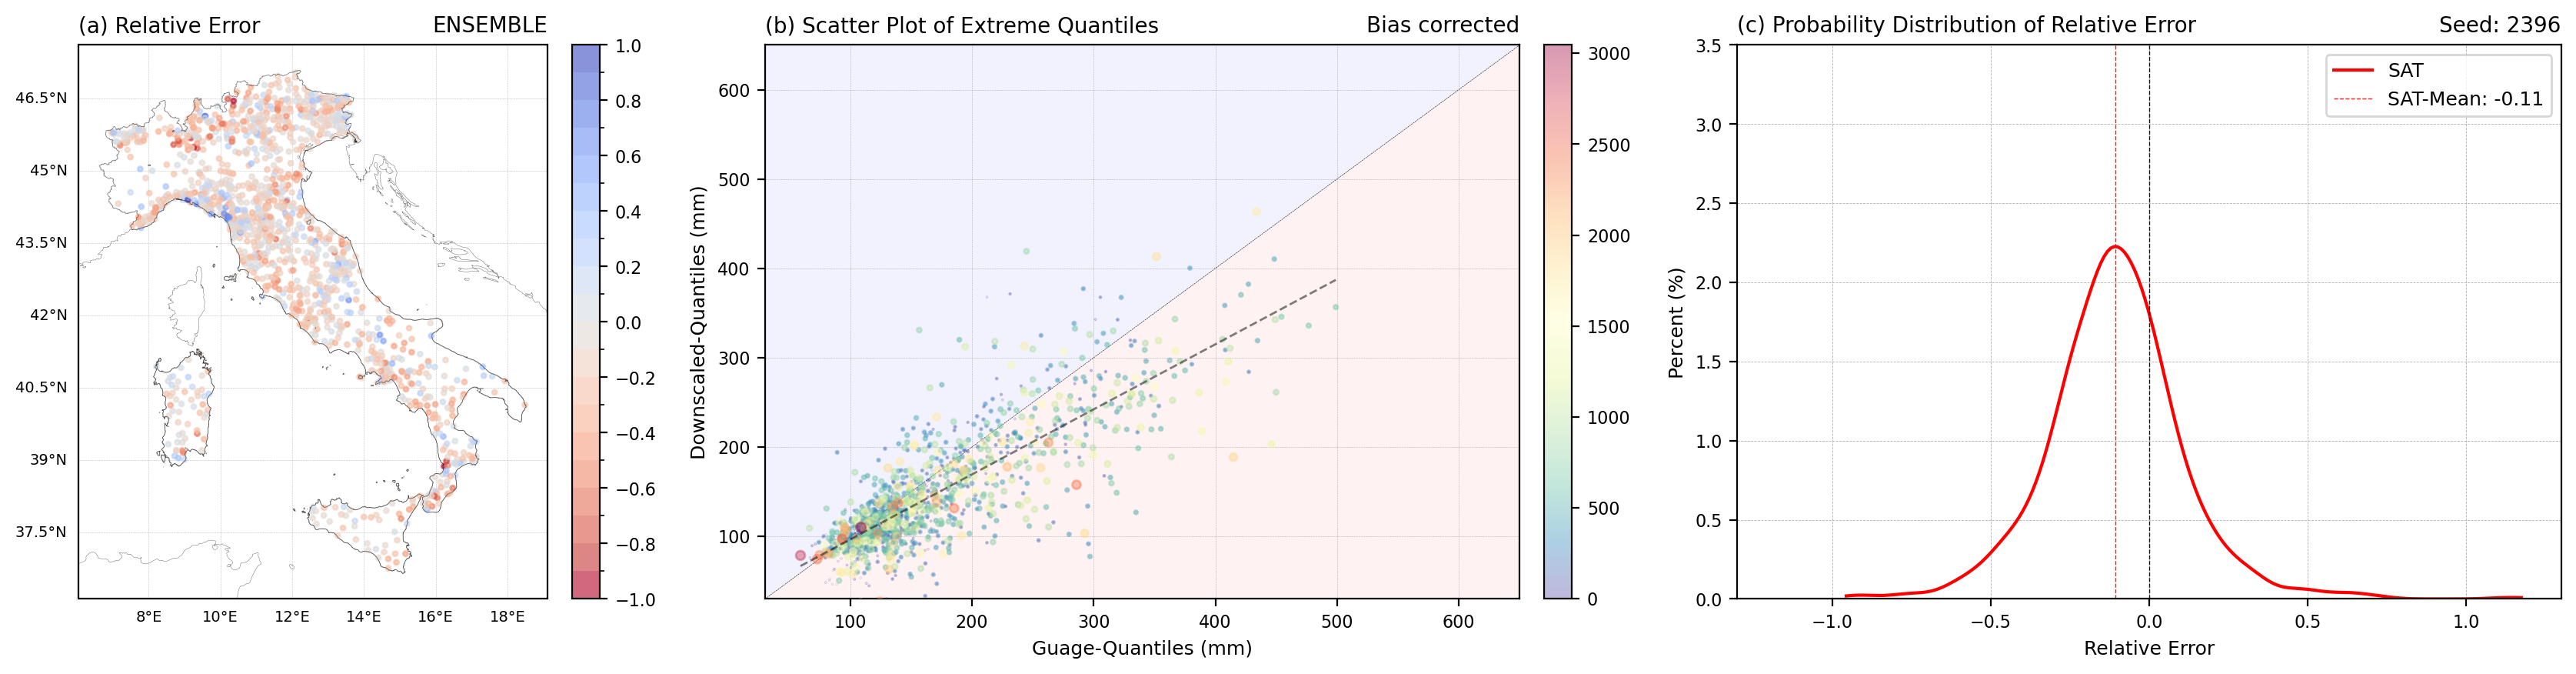

In [105]:
val_max = 600
vmin = PD_RE.Elev.min()
vmax = PD_RE.Elev.max()

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(20,4),dpi=200)
gs = gridspec.GridSpec(1,3)

# ======================================================================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)

a1 = ax1.scatter(
    PD_RE['Lon'],
    PD_RE['Lat'],
    c=PD_RE['RE_SAT'],
    cmap=scatter_cmap,
    s=5,
    norm=RE_norm,
    alpha=0.6,
    zorder=20
    )

gl = ax1.gridlines(crs=proj,draw_labels=True,linewidth=0.2,color='gray',alpha=0.5,linestyle='--')
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = False
gl.left_labels = True
gl.right_labels = False
gl.xlabel_style = {'size': 7, 'color': 'k'}
gl.ylabel_style = {'size': 7, 'color': 'k'}

cbar = plt.colorbar(a1, fraction=0.054, pad=0.03, ticks=RE_ticks)
cbar.ax.tick_params(labelsize=8)

ax1.set_title('(a) Relative Error',fontsize=10, loc='left')
ax1.set_title(product,fontsize=10, loc='right')

# ======================================================================================================================================================
ax1 = plt.subplot(gs[0, 1])
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_xlim(30,val_max+50)
ax1.set_ylim(30,val_max+50)
ax1.grid(linestyle='--', linewidth=0.2)
ax1.tick_params(axis='both', which='major', labelsize=8)

xlim = ax1.get_xlim()
ylim = ax1.get_ylim()

xlim = ax1.get_xlim()
ylim = ax1.get_ylim()
x_vals = np.linspace(min(xlim[0], ylim[0]), max(xlim[1], ylim[1]), 200)
ax1.fill_between(x_vals, ylim[0], x_vals, facecolor="red", alpha=0.05, zorder=0)
ax1.fill_between(x_vals, x_vals, ylim[1], facecolor="blue", alpha=0.05, zorder=0)

ax1.plot(np.arange(val_max+50),np.arange(val_max+50),'--k', linewidth=0.2, label='Identity line')
ax1.scatter([],[], s=5, c='darkred', label='Ensemble Satellite')
ax1.scatter([],[], s=5, c='darkblue', label='Ensemble Downscaled')

a1 = ax1.scatter(
    PD_RE.Mevd_OBS, PD_RE.Mevd_SAT,
    alpha=0.4,
    s=PD_RE.Elev_norm*20,
    c=PD_RE.Elev,
    vmin=vmin, vmax=vmax,
    zorder=10, cmap="Spectral_r")

ax1.plot(VAL_x, VAL_y, "--k", linewidth=1, label="Linear Fit", alpha=0.5,zorder=12)

ax1.set_title('(b) Scatter Plot of Extreme Quantiles',fontsize=10, loc='left')
ax1.set_title('Bias corrected',fontsize=10, loc='right')
ax1.set_xlabel('Guage-Quantiles (mm)',fontsize=9)
ax1.set_ylabel('Downscaled-Quantiles (mm)',fontsize=9)

cbar = plt.colorbar(a1, fraction=0.054, pad=0.03, ticks=None)
cbar.ax.tick_params(labelsize=8)

# ======================================================================================================================================================
ax1 = plt.subplot(gs[0, 2])
sns.kdeplot(PD_RE.RE_SAT,color='r', linestyle='-',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'SAT',
            clip=(np.nanmin(np.array(PD_RE.RE_SAT)), np.nanmax(np.array(PD_RE.RE_SAT))))

ax1.axvline(np.nanmean(PD_RE.RE_SAT), color='r',linestyle='--',linewidth=0.5,alpha=0.9, label=f'SAT-Mean: {np.round(np.nanmean(PD_RE.RE_SAT),2)}')

ax1.axvline(0, color='k',linestyle='--',linewidth=0.5,alpha=0.9)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_xlim(-1.3,1.3)
ax1.set_ylim(0,3.5)
ax1.tick_params(axis='both', which='major', labelsize=8)
ax1.set_ylabel('Percent (%)',fontsize=9)
ax1.set_xlabel('Relative Error',fontsize=9)
ax1.legend(fontsize=9, loc=0, ncol=1)

ax1.set_title('(c) Probability Distribution of Relative Error',fontsize=10, loc='left')
ax1.set_title(f'Seed: {seed}',fontsize=10, loc='right')

# ======================================================================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.18, hspace=0.13)

dir_out = os.path.join('..','..','figures','RE','corrected',f'SAT_ALL_{product}_{str(seed).zfill(3)}.png')
print(F'Export as: {dir_out}')
plt.savefig(dir_out,transparent = False,bbox_inches ='tight',pad_inches = 0.1, facecolor=None)